# ToolNode and ToolCondition : 

In [37]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict ,Annotated
from langchain_core.messages import HumanMessage , BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode , tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import os

import requests
import random
import os 

In [38]:
load_dotenv()

True

In [39]:
os.environ["LANGCHAIN_PROJECT"] = "toolsInLanggraph"


In [40]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

In [41]:
# ============================================================
# PREBUILT TOOL
# ============================================================

search_tool = DuckDuckGoSearchRun(
    region="us-en"
)


# ============================================================
# CUSTOM TOOL : we must give docstring(which tells what this tool does)
# ============================================================

@tool
def calculator(
    first_num: float,
    second_num: float,
    operation: str
) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.  
    Supported operations:
    add, sub, mul, div
    """

    try:

        if operation == "add":
            result = first_num + second_num

        elif operation == "sub":
            result = first_num - second_num

        elif operation == "mul":
            result = first_num * second_num

        elif operation == "div":

            if second_num == 0:
                return {
                    "status": "error",
                    "message": "Division by zero is not allowed."
                }

            result = first_num / second_num

        else:
            return {
                "status": "error",
                "message": (
                    "Invalid operation. "
                    "Supported operations: add, sub, mul, div"
                )
            }

        return {
            "status": "success",
            "result": result
        }

    except Exception as e:

        return {
            "status": "error",
            "message": str(e)
        }


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch the latest stock price for a given US stock symbol.

    Example:
    AAPL, TSLA, MSFT, GOOGL
    """

    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")

    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE"
        f"&symbol={symbol.upper()}"
        f"&apikey={api_key}"
    )

    response = requests.get(url, timeout=10)

    response.raise_for_status()

    data = response.json()

    return data

In [42]:
# Make tool list :

tools = [get_stock_price , search_tool , calculator]

# Make the llm tool_aware : 

llm_with_tools = llm.bind_tools(tools)

In [43]:
# state : 
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] ,add_messages]

In [44]:
# graph nodes 

def chat_node(state : ChatState):
    """
    LLM node that may answer or request a tool call.
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {
        'messages': [response]
    }

# tool node :

tool_node = ToolNode(tools) # execute tool calls 

In [45]:
# graph :

graph = StateGraph(ChatState)
graph.add_node('chat_node' , chat_node)
graph.add_node("tools" , tool_node)

In [46]:
# edges : 

graph.add_edge(START , "chat_node")

# If the LLm asked for a tool , go to ToolNode ; else finish :

graph.add_conditional_edges("chat_node" , tools_condition)

# loop : for better answers/outputs 

graph.add_edge("tools" , "chat_node")

In [47]:
chat_bot = graph.compile()

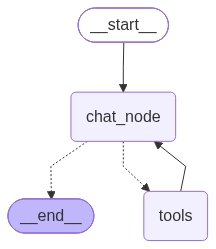

In [48]:
chat_bot

In [49]:
# Regular chat : 

out = chat_bot.invoke({
    "messages": [
        HumanMessage(content="What are today's headlines?")
    ]
})

print(out["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 56.811823656s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
out = chat_bot.invoke({
    'messages' : [HumanMessage(content="When is samay raina 's next show")]
})

print(out['messages'][-1].text)

Get Samay Raina live show tickets, comedy tour dates, biography, viral news and daily fan updates in one place. Are there VIP or meet-and-greet tickets available for the Samay Raina tour? Select dates offer VIP tiers with preferred seating and limited post-show photo opportunities. 16 hours ago · View confirmed Samay Raina tour dates with venues and showtimes. Updated as announced. Samay Raina tour dates for 2026–2027 are listed below with confirmed venues, showtimes, and city details. Browse the schedule to check availability and view current ticket price ranges for each performance. Prices vary by date, venue, and seating section. Jul 31, 2025 · Comedian Samay Raina is all set to embark on his 2025 India tour titled “Still Alive & Unfiltered,” bringing fresh laughs to major cities across the country. From tour dates to ticket booking details, here’s everything you need to know. Jul 30, 2025 · Samay Raina’s comedy tour is finally here! From Bengaluru to Delhi, here are the show dates,